# Chopard Watch Pricing - Exploratory Data Analysis

This notebook walks through the EDA process step-by-step.

**What we'll cover:**
1. Load and inspect the data
2. Check data quality (missing values, data types)
3. Analyze categorical variables (collections, countries)
4. Analyze pricing distribution
5. Compare prices across collections and regions
6. Create visualizations

---

## Setup & Configuration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:,.2f}'.format)

# Plot style
plt.style.use('seaborn-v0_8-whitegrid')

print("Libraries loaded.")

Libraries loaded.


## Data Loading & Initial Inspection

In [2]:
# Load the processed dataset
df = pd.read_csv('../data/final_processed_data.csv')

print(f"Dataset loaded: {df.shape[0]} rows, {df.shape[1]} columns")

Dataset loaded: 990 rows, 12 columns


## Data Quality & Missing Values Check

In [4]:
# See all column names
print("Columns:")
for i, col in enumerate(df.columns, 1):
    print(f"  {i}. {col}")

Columns:
  1. brand
  2. url
  3. image_url
  4. collection
  5. reference_code
  6. price
  7. currency
  8. country
  9. life_span_date
  10. category
  11. scrapping_date
  12. price_eur


In [5]:
# First 5 rows
df.head()

,brand,url,image_url,collection,reference_code,price,currency,country,life_span_date,category,scrapping_date,price_eur
0,Chopard,https://www.chopard.com/fr-ch/watch/298617-300...,"https://objects-prod.cdn.chopard.com/q_auto,f_...",ALPINE EAGLE,298617-3001,"10,600.00",CHF,Switzerland,2025-01-28 00:00:00,Watches,2025-01-06,"11,546.84"
1,Chopard,https://www.chopard.com/fr-ch/watch/298601-300...,"https://objects-prod.cdn.chopard.com/q_auto,f_...",ALPINE EAGLE,298601-3001,"11,000.00",CHF,Switzerland,2025-01-28 00:00:00,Watches,2025-01-06,"11,982.57"
2,Chopard,https://www.chopard.com/fr-ch/watch/298600-300...,"https://objects-prod.cdn.chopard.com/q_auto,f_...",ALPINE EAGLE,298600-3001,"14,000.00",CHF,Switzerland,2025-01-28 00:00:00,Watches,2025-01-06,"15,250.54"
3,Chopard,https://www.chopard.com/fr-ch/watch/298600-300...,"https://objects-prod.cdn.chopard.com/q_auto,f_...",ALPINE EAGLE,298600-3002,"14,000.00",CHF,Switzerland,2025-01-28 00:00:00,Watches,2025-01-06,"15,250.54"
4,Chopard,https://www.chopard.com/fr-ch/watch/298617-300...,"https://objects-prod.cdn.chopard.com/q_auto,f_...",ALPINE EAGLE,298617-3002,"14,300.00",CHF,Switzerland,2025-01-28 00:00:00,Watches,2025-01-06,"15,577.34"


In [6]:
# Data types
print("Data Types:")
print(df.dtypes)

Data Types:
brand              object
url                object
image_url          object
collection         object
reference_code     object
price             float64
currency           object
country            object
life_span_date     object
category           object
scrapping_date     object
price_eur         float64
dtype: object


## Step 4: Check for Missing Values

In [7]:
# Count missing values
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    'Column': missing.index,
    'Missing': missing.values,
    'Percent': missing_pct.values
})

print("Missing Values:")
print(missing_df.to_string(index=False))

Missing Values:
        Column  Missing  Percent
         brand        0     0.00
           url        0     0.00
     image_url        0     0.00
    collection        0     0.00
reference_code        0     0.00
         price        0     0.00
      currency        0     0.00
       country        0     0.00
life_span_date        0     0.00
      category        0     0.00
scrapping_date        0     0.00
     price_eur        0     0.00


## Step 5: Unique Values

In [8]:
# Count unique values per column
print("Unique Values:")
for col in df.columns:
    print(f"  {col}: {df[col].nunique()}")

Unique Values:
  brand: 1
  url: 990
  image_url: 203
  collection: 7
  reference_code: 203
  price: 606
  currency: 5
  country: 5
  life_span_date: 1
  category: 1
  scrapping_date: 1
  price_eur: 739


## Step 6: Categorical Analysis

In [9]:
# Collection distribution
print("Collections:")
print(df['collection'].value_counts())

Collections:
collection
HAPPY SPORT           397
ALPINE EAGLE          160
L'HEURE DU DIAMANT    155
L.U.C                 116
IMPERIALE              70
MILLE MIGLIA           61
HAPPY DIAMONDS         31
Name: count, dtype: int64


In [10]:
# Country distribution
print("Countries:")
print(df['country'].value_counts())

Countries:
country
USA            199
Japan          199
France         198
Switzerland    197
UK             197
Name: count, dtype: int64


In [11]:
# Currency distribution
print("Currencies:")
print(df['currency'].value_counts())

Currencies:
currency
USD    199
JPY    199
EUR    198
CHF    197
GBP    197
Name: count, dtype: int64


## Step 7: Price Statistics

In [12]:
# Basic price stats
print("Price Statistics (EUR):")
print(f"  Count:  {df['price_eur'].count():,}")
print(f"  Mean:   {df['price_eur'].mean():,.0f} EUR")
print(f"  Median: {df['price_eur'].median():,.0f} EUR")
print(f"  Min:    {df['price_eur'].min():,.0f} EUR")
print(f"  Max:    {df['price_eur'].max():,.0f} EUR")
print(f"  Std:    {df['price_eur'].std():,.0f} EUR")

Price Statistics (EUR):
  Count:  990
  Mean:   30,294 EUR
  Median: 18,486 EUR
  Min:    3,753 EUR
  Max:    110,000 EUR
  Std:    26,542 EUR


## Pricing Distribution 

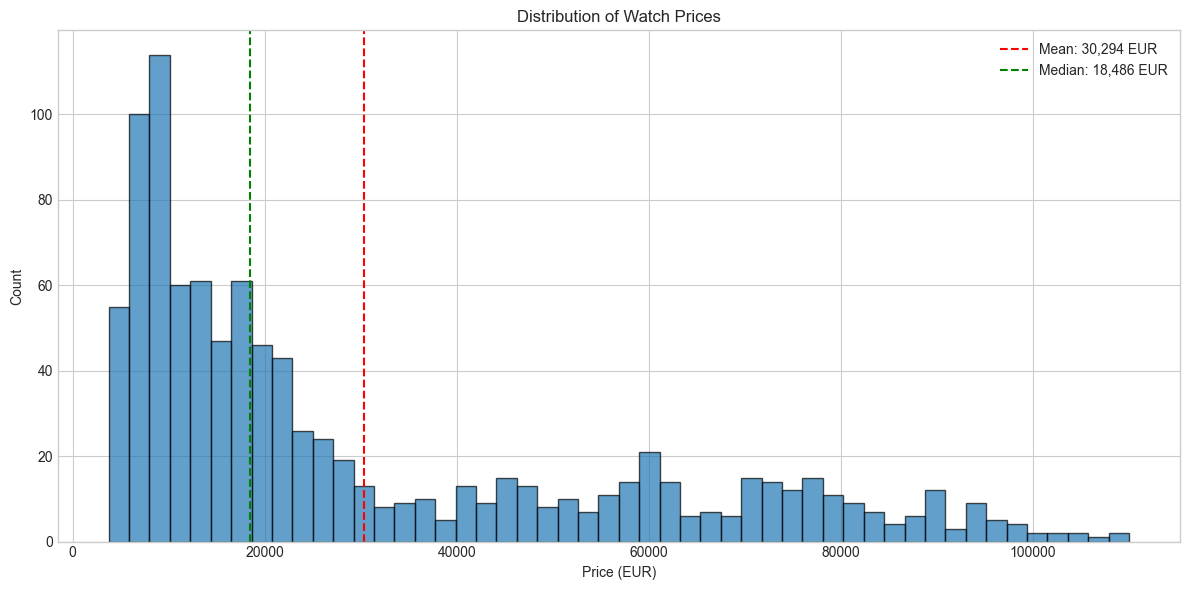

In [13]:
# Histogram of prices
plt.figure(figsize=(12, 6))
plt.hist(df['price_eur'], bins=50, edgecolor='black', alpha=0.7)
plt.axvline(df['price_eur'].mean(), color='red', linestyle='--', label=f"Mean: {df['price_eur'].mean():,.0f} EUR")
plt.axvline(df['price_eur'].median(), color='green', linestyle='--', label=f"Median: {df['price_eur'].median():,.0f} EUR")
plt.xlabel('Price (EUR)')
plt.ylabel('Count')
plt.title('Distribution of Watch Prices')
plt.legend()
plt.tight_layout()
plt.show()

# The distribution is right-skewed - most watches are in lower price ranges

## Collection Analysis

In [14]:
# Stats by collection
collection_stats = df.groupby('collection')['price_eur'].agg(['count', 'mean', 'median', 'min', 'max']).round(0)
collection_stats = collection_stats.sort_values('mean', ascending=False)
print("Price by Collection:")
print(collection_stats)

Price by Collection:
                    count      mean    median       min        max
collection                                                        
L'HEURE DU DIAMANT    155 69,809.00 70,370.00 37,227.00 110,000.00
ALPINE EAGLE          160 39,206.00 26,026.00  9,007.00  98,600.00
L.U.C                 116 33,427.00 28,835.00  9,547.00  90,300.00
IMPERIALE              70 24,817.00 12,876.00  5,734.00 101,000.00
HAPPY DIAMONDS         31 19,249.00 18,627.00  7,926.00  36,000.00
HAPPY SPORT           397 15,489.00 11,111.00  3,753.00 108,500.00
MILLE MIGLIA           61  8,805.00  8,947.00  5,194.00  13,000.00


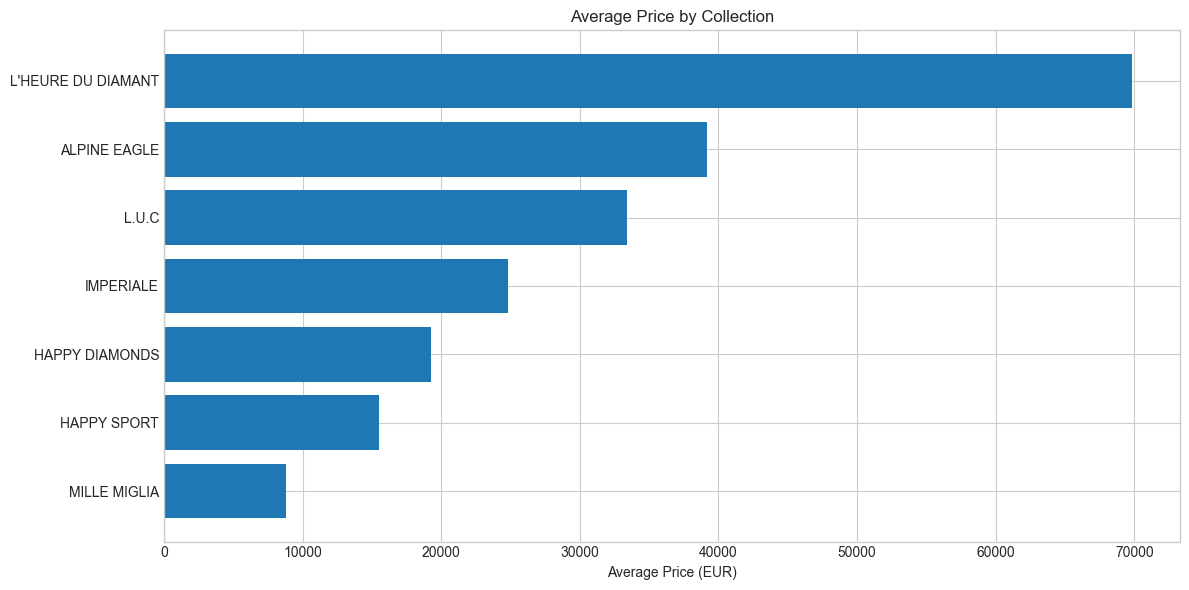

In [15]:
# Bar chart of average price by collection
plt.figure(figsize=(12, 6))
collection_means = df.groupby('collection')['price_eur'].mean().sort_values(ascending=True)
plt.barh(collection_means.index, collection_means.values)
plt.xlabel('Average Price (EUR)')
plt.title('Average Price by Collection')
plt.tight_layout()
plt.show()

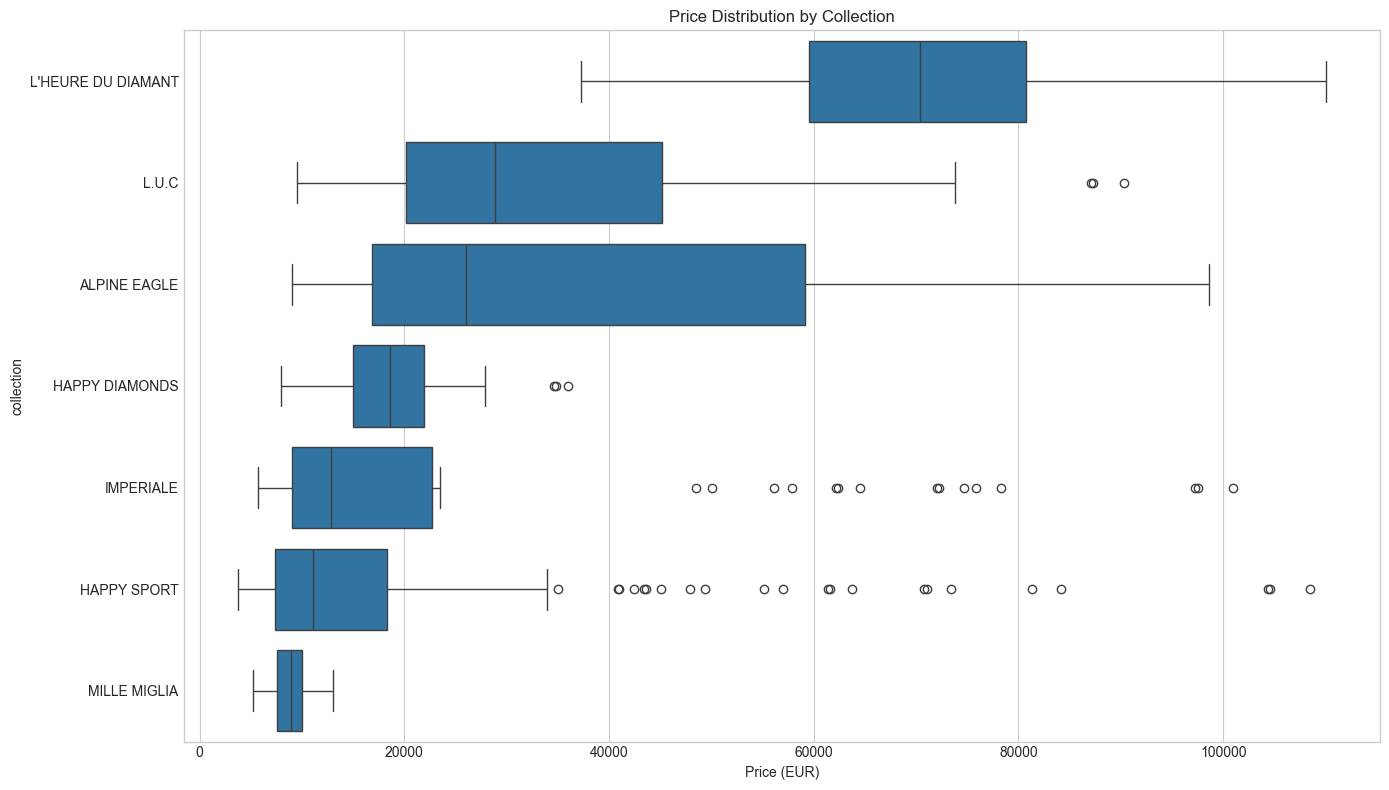

In [16]:
# Box plot by collection
plt.figure(figsize=(14, 8))
order = df.groupby('collection')['price_eur'].median().sort_values(ascending=False).index
sns.boxplot(data=df, x='price_eur', y='collection', order=order)
plt.xlabel('Price (EUR)')
plt.title('Price Distribution by Collection')
plt.tight_layout()
plt.show()

## Step 10: Price by Country

In [17]:
# Stats by country
country_stats = df.groupby('country')['price_eur'].agg(['count', 'mean', 'median']).round(0)
country_stats = country_stats.sort_values('mean', ascending=False)
print("Price by Country:")
print(country_stats)

Price by Country:
             count      mean    median
country                               
France         198 34,252.00 21,100.00
UK             197 33,063.00 20,300.00
Switzerland    197 32,655.00 20,153.00
USA            199 26,099.00 15,833.00
Japan          199 25,471.00 15,311.00


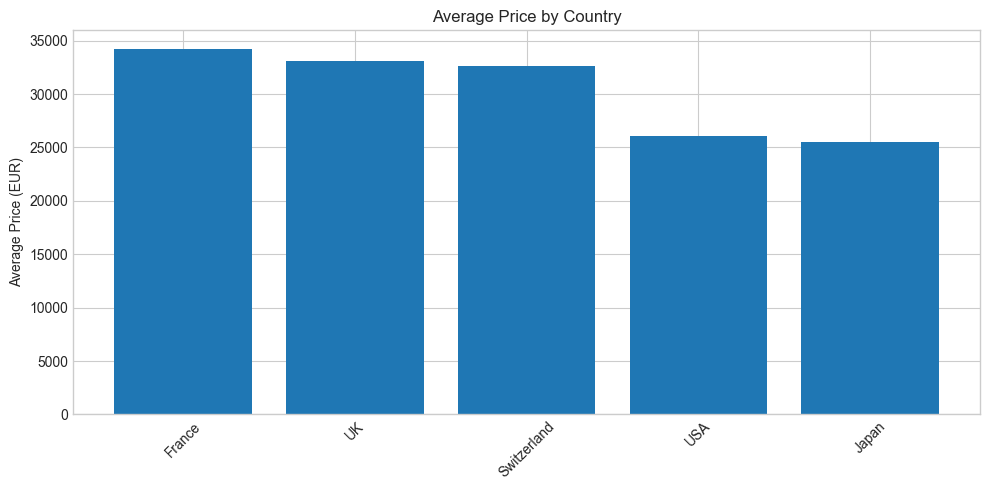

In [18]:
# Bar chart by country
plt.figure(figsize=(10, 5))
country_means = df.groupby('country')['price_eur'].mean().sort_values(ascending=False)
plt.bar(country_means.index, country_means.values)
plt.ylabel('Average Price (EUR)')
plt.title('Average Price by Country')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Step 11: Top and Bottom Priced Watches

In [19]:
# Most expensive watches
cols = [c for c in ['title', 'collection', 'reference_code', 'price_eur', 'country'] if c in df.columns]

print("Top 10 Most Expensive:")
print(df.nlargest(10, 'price_eur')[cols].to_string(index=False))

Top 10 Most Expensive:
        collection reference_code  price_eur     country
L'HEURE DU DIAMANT    139383-1201 110,000.00      France
       HAPPY SPORT    274809-1001 108,500.00      France
L'HEURE DU DIAMANT    139383-1201 105,882.35          UK
       HAPPY SPORT    274809-1001 104,613.61          UK
       HAPPY SPORT    274809-1001 104,357.30 Switzerland
L'HEURE DU DIAMANT    139383-1201 103,050.11 Switzerland
L'HEURE DU DIAMANT    139419-1601 103,000.00      France
         IMPERIALE    385388-5001 101,000.00      France
L'HEURE DU DIAMANT    139419-1601  99,423.30          UK
      ALPINE EAGLE    295363-5011  98,600.00      France


In [20]:
# Least expensive watches
print("Top 10 Least Expensive:")
print(df.nsmallest(10, 'price_eur')[cols].to_string(index=False))

Top 10 Least Expensive:
 collection reference_code  price_eur country
HAPPY SPORT    278620-3001   3,752.73   Japan
HAPPY SPORT    278620-3001   3,875.00     USA
HAPPY SPORT    278590-3001   3,932.86   Japan
HAPPY SPORT    278620-3003   3,962.88   Japan
HAPPY SPORT    278620-3005   3,962.88   Japan
HAPPY SPORT    278620-3004   3,962.88   Japan
HAPPY SPORT    278620-6003   4,052.95   Japan
HAPPY SPORT    278590-3001   4,058.33     USA
HAPPY SPORT    278620-3004   4,075.00     USA
HAPPY SPORT    278620-3003   4,075.00     USA


## Step 12: Collection Breakdown (Pie Chart)

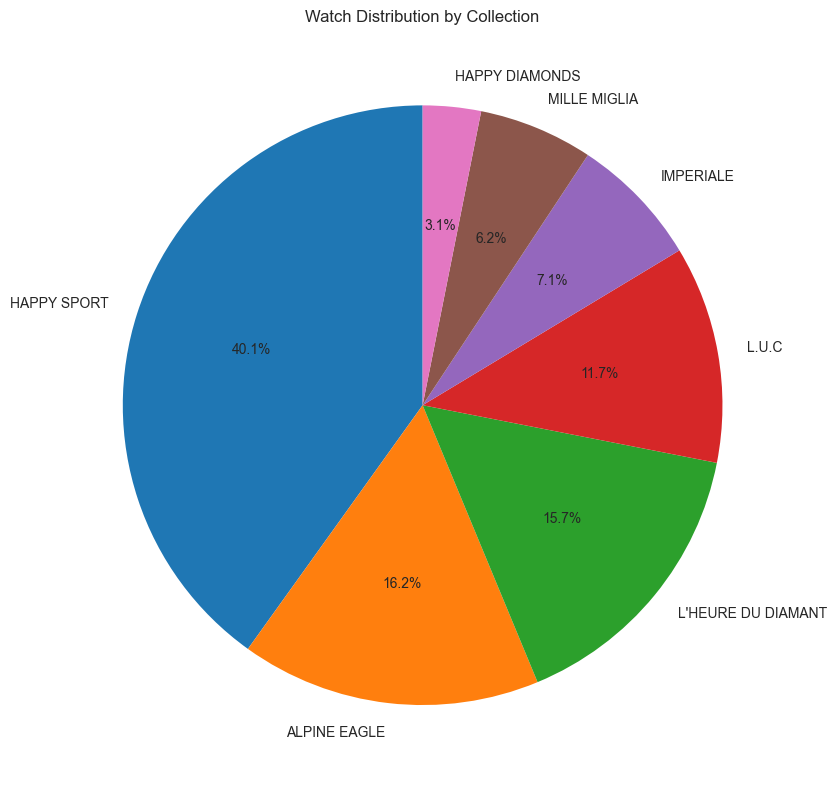

In [21]:
# Pie chart of collections
collection_counts = df['collection'].value_counts()

plt.figure(figsize=(10, 8))
plt.pie(collection_counts.values, labels=collection_counts.index, autopct='%1.1f%%', startangle=90)
plt.title('Watch Distribution by Collection')
plt.tight_layout()
plt.show()

## Step 13: Key Findings

In [22]:
print("=" * 50)
print("KEY FINDINGS")
print("=" * 50)

print(f"\nDataset:")
print(f"  - Total watches: {len(df):,}")
print(f"  - Collections: {df['collection'].nunique()}")
print(f"  - Countries: {df['country'].nunique()}")

print(f"\nPricing:")
print(f"  - Range: {df['price_eur'].min():,.0f} - {df['price_eur'].max():,.0f} EUR")
print(f"  - Average: {df['price_eur'].mean():,.0f} EUR")
print(f"  - Median: {df['price_eur'].median():,.0f} EUR")

most_expensive = df.groupby('collection')['price_eur'].mean().idxmax()
least_expensive = df.groupby('collection')['price_eur'].mean().idxmin()
print(f"\nCollections:")
print(f"  - Most expensive: {most_expensive}")
print(f"  - Least expensive: {least_expensive}")

KEY FINDINGS

Dataset:
  - Total watches: 990
  - Collections: 7
  - Countries: 5

Pricing:
  - Range: 3,753 - 110,000 EUR
  - Average: 30,294 EUR
  - Median: 18,486 EUR

Collections:
  - Most expensive: L'HEURE DU DIAMANT
  - Least expensive: MILLE MIGLIA


---

## Summary

Key points to remember for interviews:

1. **Data Quality**: Checked for missing values and data types
2. **Statistics**: Calculated mean, median, min, max for prices
3. **Visualizations**: Used histograms, bar charts, box plots, and pie charts
4. **Insights**: Identified pricing patterns by collection and region

---

**Next Steps**: Use these insights for machine learning models and Power BI dashboards.